<a href="https://colab.research.google.com/github/OpusArtisbyRawlz/spy-risk-volatility-model/blob/main/Another_copy_of_spy_volatility_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPY Volatility & Risk Modelling
## Project 2 - Quant Research Portfolio

Goal:
Model and forecast short-horizon risk metrics (realised volatility, volatility regimes, and drawdown probability) using walk-forward validation and baseline-first evaluation.

# Project 2 — SPY Volatility & Risk Modeling (Walk-Forward)

## Hypothesis
Volatility clusters: recent realized volatility contains information about future realized volatility.
Therefore, forecasting next 5-day realized volatility should beat a naïve baseline in walk-forward evaluation.

## Target
Next 5-day realized volatility (RV_5d_fwd), computed from returns t+1...t+5.

## Evaluation
Walk-forward validation with a strong baseline.
Primary metric: MAE (and RMSE optional).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score


# If you already have `spy` loaded from earlier work, you can skip the download part.
import yfinance as yf

spy = yf.download("SPY", start="2010-01-01", end="2026-01-31", progress=False)
spy = spy[["Close"]].copy()

# --- Returns ---
spy["ret_1d"] = spy["Close"].pct_change()

spy["ret_fwd_1d"] = spy["ret_1d"].shift(-1)
# --- FUTURE 5-day realized volatility (target) ---
# Use returns from t+1..t+5 (forward-looking). This avoids leakage.
# We compute forward RV by shifting returns up by 1 and taking a rolling std over 5 days.
spy["RV5_fwd"] = spy["ret_1d"].shift(-1).rolling(5).std()

# Optional: annualize (common in practice). Comment out if you want raw 5-day vol.
spy["RV5_fwd_ann"] = spy["RV5_fwd"] * np.sqrt(252)

# --- TRAILING realized volatility (baseline feature) ---
spy["RV20_trail"] = spy["ret_1d"].rolling(20).std() * np.sqrt(252)
spy["RV5_trail"]  = spy["ret_1d"].rolling(5).std()  * np.sqrt(252)

# Drop rows with NaNs created by rolling windows and shifting
spy = spy.dropna().copy()

# Choose target
y = spy["RV5_fwd_ann"]  # or use "RV5_fwd" if you want non-annualized

# Baseline prediction: predict next-week vol as current trailing 20d vol
baseline_pred = spy["RV20_trail"]

print("Target mean (ann RV):", y.mean())
print("Baseline mean (RV20):", baseline_pred.mean())

N = len(spy)
train_size=1000
test_size=126

print("N:", N)
print("Windows implied:", (N - train_size)//test_size)

print("First date kept:", spy.index.min())
print("Last date kept:", spy.index.max())


/tmp/ipython-input-394/784109555.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="2010-01-01", end="2026-01-31", progress=False)


Target mean (ann RV): 0.13747517764525757
Baseline mean (RV20): 0.14673366983224537
N: 4023
Windows implied: 23
First date kept: 2010-02-02 00:00:00
Last date kept: 2026-01-29 00:00:00


We use daily SPY data downloaded from Yahoo Finance and construct realized-volatility targets and baseline with strict temporal alignment to avoid look-ahead bias

*   **Sample Period** : 2010-02-02 to 2026-01-29
*   **Total usable observations** - 4023
*   **Walk-forward evaluation** : 23 rolling windows
*   **Train / test split** : 1,000 trading days train, 126 trading days test (≈ 6 months)

Here, we considered RV20 day volatility as the baseline because its the strongest simple, defensible, industry-standard baseline for forecasting short-horizon volatility. 20 days is equivalent to one trading month.

reason returns are considered not prices are additive in *log spaces, multiplicative in wealth space and independent of starting capital*. They are correct object for *sharpe, drawdown, compounding and risk analysis.*

### **Walk-forward evaluation for the baseline**

In [ ]:
def walk_forward_regression_errors(y_true_series, y_pred_series, train_size=1000, test_size=126):
    """
    Walk-forward evaluation for regression.
    Returns arrays of per-window MAE and RMSE.
    """
    y_true_series = y_true_series.reset_index(drop=True)
    y_pred_series = y_pred_series.reset_index(drop=True)

    maes, rmses = [], []
    start = 0

    while start + train_size + test_size <= len(y_true_series):
        y_true = y_true_series.iloc[start + train_size : start + train_size + test_size]
        y_pred = y_pred_series.iloc[start + train_size : start + train_size + test_size]

        err = (y_true - y_pred).values
        mae = np.mean(np.abs(err))
        rmse = np.sqrt(np.mean(err**2))

        maes.append(mae)
        rmses.append(rmse)

        start += test_size

    return np.array(maes), np.array(rmses)

mae_base, rmse_base = walk_forward_regression_errors(y, baseline_pred, train_size=1000, test_size=126)

print("Baseline Num Windows:", len(mae_base))
print("Baseline MAE mean:", mae_base.mean(), "std:", mae_base.std())
print("Baseline RMSE mean:", rmse_base.mean(), "std:", rmse_base.std())


Baseline Num Windows: 23
Baseline MAE mean: 0.050159392426633434 std: 0.02570914504094163
Baseline RMSE mean: 0.06692567507027944 std: 0.03984730515576033


### **Defining features**

In [ ]:
# --- Feature matrix for Model 1 ---
X = pd.DataFrame({
    "RV5_trail": spy["RV5_trail"],
    "RV20_trail": spy["RV20_trail"],
})

X["VolRatio"] = X["RV5_trail"] / X["RV20_trail"]

# Target (already defined earlier)
y = spy["RV5_fwd_ann"]

print(X.head())
print("Any NaNs:", X.isna().any().any())


            RV5_trail  RV20_trail  VolRatio
Date                                       
2010-02-02   0.200861    0.168030  1.195388
2010-02-03   0.204353    0.167857  1.217423
2010-02-04   0.298182    0.196891  1.514450
2010-02-05   0.292994    0.195957  1.495197
2010-02-08   0.252677    0.194776  1.297272
Any NaNs: False


**RV5_trail** - Fast-reacting volatility

**RV_20_trail** - regime anchor

**VolRatio**= RV5/RV20 - Regime change signal

### **Walk-forward regression model (Ridge) vs Baseline**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def walk_forward_model_vs_baseline(X, y, baseline_pred, train_size=1000, test_size=126, alpha=1.0):
    model_mae, base_mae = [], []
    model_rmse, base_rmse = [], []

    start = 0
    while start + train_size + test_size <= len(X):
        X_train = X.iloc[start:start+train_size]
        y_train = y.iloc[start:start+train_size]

        X_test = X.iloc[start+train_size:start+train_size+test_size]
        y_test = y.iloc[start+train_size:start+train_size+test_size]

        base_pred = baseline_pred.iloc[start+train_size:start+train_size+test_size]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=alpha))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        # Errors
        err_model = y_test.values - pred
        err_base  = y_test.values - base_pred.values

        model_mae.append(np.mean(np.abs(err_model)))
        base_mae.append(np.mean(np.abs(err_base)))

        model_rmse.append(np.sqrt(np.mean(err_model**2)))
        base_rmse.append(np.sqrt(np.mean(err_base**2)))

        start += test_size

    return (
        np.array(model_mae), np.array(base_mae),
        np.array(model_rmse), np.array(base_rmse)
    )

In [ ]:
model_mae, base_mae, model_rmse, base_rmse = walk_forward_model_vs_baseline(
    X, y, baseline_pred, train_size=1000, test_size=126, alpha=1.0
)

print("Num windows:", len(model_mae))

print("MAE — Model mean:", model_mae.mean(), "std:", model_mae.std())
print("MAE — Base  mean:", base_mae.mean(),  "std:", base_mae.std())
print("MAE Improvement (base - model):", (base_mae - model_mae).mean())

print("\nRMSE — Model mean:", model_rmse.mean(), "std:", model_rmse.std())
print("RMSE — Base  mean:", base_rmse.mean(),  "std:", base_rmse.std())
print("RMSE Improvement (base - model):", (base_rmse - model_rmse).mean())


Num windows: 23
MAE — Model mean: 0.025309806689117798 std: 0.010911198481603645
MAE — Base  mean: 0.050159392426633434 std: 0.02570914504094163
MAE Improvement (base - model): 0.02484958573751564

RMSE — Model mean: 0.03911139383851453 std: 0.019526833535403534
RMSE — Base  mean: 0.06692567507027944 std: 0.03984730515576033
RMSE Improvement (base - model): 0.02781428123176492


Using a walk-forward validation framework with 23 rolling windows, the model consistently outperforms the constant-mean baseline across both error metrics. The model achieves a mean MAE of 0.0253 compared to 0.0502 for the baseline, representing an improvement of approximately 50%, with lower variability across windows. Similarly, the model’s RMSE of 0.0391 is substantially lower than the baseline RMSE of 0.0669, indicating reduced sensitivity to large forecast errors and improved robustness during higher-volatility periods. Taken together, these results suggest that the model captures meaningful time-varying structure in realized volatility rather than simply reverting to the unconditional mean, making it more suitable for downstream risk estimation and position-sizing applications

### **Inspect Coefficients & Intuition**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

pipe.fit(X, y)

coefs = pd.Series(
    pipe.named_steps["model"].coef_,
    index=X.columns
)

intercept = pipe.named_steps["model"].intercept_

coefs, intercept


(RV5_trail     0.099561
 RV20_trail    0.002487
 VolRatio     -0.003797
 dtype: float64,
 np.float64(0.13747517764525757))

The estimated coefficients indicate that short-horizon volatility dynamics dominate the model’s predictive signal. The positive coefficient on RV5_trail (0.0996) suggests that recent volatility over the past week carries the strongest influence on the forecast, consistent with volatility clustering and short-term persistence. In contrast, the coefficient on RV20_trail (0.0025) is close to zero, implying that longer-horizon trailing volatility contributes little incremental information once short-term effects are accounted for. The slightly negative coefficient on VolRatio (−0.0038) indicates a mild mean-reverting adjustment, where elevated short-term volatility relative to the longer-term baseline marginally reduces the forecast.

**RV_fwd = B1.RV5_trail + B2.RV_20_trail + B3.VolRatio** (so higher short term volatility does not linearly increases the RV_fwd because the VolRatio dampens the forward volatility)

Overall, the coefficient structure aligns with financial intuition: volatility is primarily driven by recent shocks, with longer-term measures acting as weak stabilizers rather than primary drivers.

### **Walk-forward regime (Loss, AUC)**

In [ ]:
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.linear_model import LogisticRegression

def walk_forward_vol_regime(
    X, y_rv, baseline_rv,
    train_size=1000, test_size=126,
    alpha_ridge=1.0,
    high_q=0.7
):
    model_losses, base_losses = [], []
    model_aucs, base_aucs = [], []

    start = 0
    while start + train_size + test_size <= len(X):
        # Split
        X_train = X.iloc[start:start+train_size]
        X_test  = X.iloc[start+train_size:start+train_size+test_size]

        y_rv_train = y_rv.iloc[start:start+train_size]
        y_rv_test  = y_rv.iloc[start+train_size:start+train_size+test_size]

        # --- Define regime threshold using TRAINING ONLY ---
        thresh = y_rv_train.quantile(high_q)

        y_train = (y_rv_train > thresh).astype(int)
        y_test  = (y_rv_test  > thresh).astype(int)

        if y_train.nunique() < 2:
            start += test_size
            continue


        # --- Volatility regression model (predict RV) ---
        reg_pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=alpha_ridge))
        ])
        reg_pipe.fit(X_train, y_rv_train)
                                                       # This could cause an optimism bias
        rv_pred_train = reg_pipe.predict(X_train)
        rv_pred_test = reg_pipe.predict(X_test)

        # --- Classification on predicted RV ---
        clf = LogisticRegression(max_iter=1000)
        clf.fit(rv_pred_train.reshape(-1,1), y_train)

        prob_model = clf.predict_proba(rv_pred_test.reshape(-1,1))[:,1]

        # --- Baseline: classify using baseline RV20 ---
        base_rv_test = baseline_rv.iloc[start+train_size:start+train_size+test_size].values
        base_prob = (base_rv_test > thresh).astype(float) * 0.9 + 0.05  # soft baseline

        # --- Metrics ---
        model_losses.append(log_loss(y_test, prob_model, labels=[0,1]))
        base_losses.append(log_loss(y_test, base_prob, labels=[0,1]))

        if len(np.unique(y_test)) > 1:
            model_aucs.append(roc_auc_score(y_test, prob_model))
            base_aucs.append(roc_auc_score(y_test, base_prob))

        start += test_size

    return (
        np.array(model_losses), np.array(base_losses),
        np.array(model_aucs), np.array(base_aucs)
    )

In [ ]:
model_ll, base_ll, model_auc, base_auc = walk_forward_vol_regime(
    X, y, baseline_pred,
    train_size=1000, test_size=126, alpha_ridge=1.0,
    high_q=0.7
)

print("Num windows:", len(model_ll))
print("\nLogLoss:")
print("Model mean:", model_ll.mean(), "std:", model_ll.std())
print("Base  mean:", base_ll.mean(),  "std:", base_ll.std())
print("Improvement (base - model):", (base_ll - model_ll).mean())

print("\nAUC:")
print("Model mean:", np.nanmean(model_auc))
print("Base  mean:", np.nanmean(base_auc))


Num windows: 23

LogLoss:
Model mean: 0.40009585561686356 std: 0.11915983937945607
Base  mean: 0.5948663978568556 std: 0.30400362876374654
Improvement (base - model): 0.1947705422399919

AUC:
Model mean: 0.9190447967718597
Base  mean: 0.6301951067031131


In this initial two-stage walk-forward setup, the volatility regressor is trained on each rolling training window and its in-sample predictions are subsequently used to fit the volatility-regime classifier. While this configuration does not reflect a production-safe workflow due to optimism bias in the regression stage, it provides a useful upper-bound benchmark on achievable regime-classification performance. Under this formulation, the model consistently and materially outperforms the baseline across 23 walk-forward windows, achieving a mean log loss of 0.40 versus 0.59 for the baseline and a mean AUC of 0.92 compared to 0.63. These results indicate strong separability between high- and low-volatility regimes when using the predicted realized volatility signal. However, because the classifier is trained on regression outputs that were generated in-sample, the reported metrics are likely optimistic. To obtain a leakage-free and deployment-consistent evaluation, the analysis therefore transitions to an out-of-fold (OOF) prediction framework for the regression stage, ensuring that all classifier inputs are strictly out-of-sample.

In [ ]:
def prob_to_weight(p, t1=0.6, t2=0.8, w_mid=0.5):
    p = np.asarray(p)
    w = np.ones_like(p, dtype=float)
    w[p >= t1] = w_mid
    w[p >= t2] = 0.0
    return w


def prob_to_weight_hysteresis(p, exit_hi=0.8, enter_lo=0.5, w_mid=0.5):
    """
    Hysteresis:
      - exit quickly when risk spikes (p >= exit_hi)
      - re-enter only after risk cools (p <= enter_lo)
      - optional middle exposure zone while invested
    """
    p = np.asarray(p)
    w = np.zeros_like(p, dtype=float)
    prev_w = 1.0  # start fully invested

    for i in range(len(p)):
        if prev_w == 1.0:
            if p[i] >= exit_hi:
                w[i] = 0.0
            elif p[i] >= enter_lo:
                w[i] = w_mid
            else:
                w[i] = 1.0
        else:
            # stay out (or stay reduced) until risk truly cools
            if p[i] <= enter_lo:
                w[i] = 1.0
            else:
                w[i] = prev_w

        prev_w = w[i]

    return w



In [ ]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression


def _ts_oof_preds(reg_pipeline, X_train, y_train, n_splits=5, min_train_size=200):
    """
    Create out-of-fold predictions for time series:
    - Expanding windows
    - Each validation fold is predicted by a model trained only on earlier data
    Returns:
      oof_pred: shape (len(X_train),) with NaN where no OOF prediction available
      valid_mask: boolean mask for rows that have OOF predictions
    """
    n = len(X_train)
    oof = np.full(n, np.nan, dtype=float)

    tscv = TimeSeriesSplit(n_splits=n_splits)

    for tr_idx, val_idx in tscv.split(X_train):
        if len(tr_idx) < min_train_size:
            continue

        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]

        reg_pipeline.fit(X_tr, y_tr)
        oof[val_idx] = reg_pipeline.predict(X_val)

    valid_mask = ~np.isnan(oof)
    return oof, valid_mask


In [ ]:
def walk_forward_reg_oof(
    X, y_rv, base_rv, ret_fwd,
    train_size=1000, test_size=126,
    alpha=1.0, high_q=0.8,
    min_train_size=200, n_splits=5
):
    # align & drop missing
    df = X.copy()
    df["_y_rv"] = y_rv
    df["_base_rv"] = base_rv
    df["_ret_fwd"] = ret_fwd
    df = df.dropna()

    X = df.drop(columns=["_y_rv", "_base_rv", "_ret_fwd"])
    y_rv = df["_y_rv"]
    base_rv = df["_base_rv"]
    ret_fwd = df["_ret_fwd"]

    n = len(X)

    # diagnostics
    total_windows = 0
    skipped_windows = 0
    train_prevalences = []
    mask_counts = []

    # per-window arrays for ROC / plotting
    y_test_list = []
    model_prob_list = []
    test_index_list = []
    base_prob_list = []
    dumb_prob_list = []

    # tradable overlay series
    all_strat_ret = []
    all_bh_ret = []
    all_w = []

    # metrics
    model_losses, base_losses, dumb_losses = [], [], []
    model_aucs, base_aucs, dumb_aucs = [], [], []

    reg_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])
    base_reg_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])

    start = 0
    while start + train_size + test_size < n:
        total_windows += 1

        tr = slice(start, start + train_size)
        te = slice(start + train_size, start + train_size + test_size)

        X_train, X_test = X.iloc[tr], X.iloc[te]
        y_rv_train, y_rv_test = y_rv.iloc[tr], y_rv.iloc[te]
        base_rv_train, base_rv_test = base_rv.iloc[tr], base_rv.iloc[te]
        ret_test = ret_fwd.iloc[te].to_numpy()

        # regime labels defined from TRAIN ONLY
        threshold = y_rv_train.quantile(high_q)
        y_train = (y_rv_train > threshold).astype(int)
        y_test = (y_rv_test > threshold).astype(int)

        if y_train.nunique() < 2:
            skipped_windows += 1
            start += test_size
            continue

        train_prevalences.append(float(y_train.mean()))

        # ----- model OOF regression -> logistic -----
        model_oof, model_mask = _ts_oof_preds(
            reg_pipeline, X_train, y_rv_train,
            n_splits=n_splits, min_train_size=min_train_size
        )
        if model_mask.sum() < 50 or y_train.iloc[model_mask].nunique() < 2:
            skipped_windows += 1
            start += test_size
            continue

        clf = LogisticRegression(max_iter=2000)
        clf.fit(model_oof[model_mask].reshape(-1, 1), y_train.iloc[model_mask])

        reg_pipeline.fit(X_train, y_rv_train)
        pred = reg_pipeline.predict(X_test).reshape(-1, 1)
        clf_prob = clf.predict_proba(pred)[:, 1]

        # ----- baseline: only RV20_trail feature -----
        base_X_train = base_rv_train.to_frame("baseline")
        base_X_test  = base_rv_test.to_frame("baseline")

        base_oof, base_mask = _ts_oof_preds(
            base_reg_pipeline, base_X_train, y_rv_train,
            n_splits=n_splits, min_train_size=min_train_size
        )

        if base_mask.sum() >= 50 and y_train.iloc[base_mask].nunique() > 1:
            base_clf = LogisticRegression(max_iter=2000)
            base_clf.fit(base_oof[base_mask].reshape(-1, 1), y_train.iloc[base_mask])

            base_reg_pipeline.fit(base_X_train, y_rv_train)
            base_pred = base_reg_pipeline.predict(base_X_test).reshape(-1, 1)
            base_prob = base_clf.predict_proba(base_pred)[:, 1]
        else:
            base_prob = np.full(len(y_test), float(y_train.mean()), dtype=float)

        # ----- dumb: constant p0 -----
        p0 = float(y_train.mean())
        dumb_prob = np.full(len(y_test), p0, dtype=float)

        # numeric safety for logloss
        eps = 1e-12
        clf_prob = np.clip(clf_prob, eps, 1-eps)
        base_prob = np.clip(base_prob, eps, 1-eps)
        dumb_prob = np.clip(dumb_prob, eps, 1-eps)

        # metrics
        model_losses.append(log_loss(y_test, clf_prob, labels=[0, 1]))
        base_losses.append(log_loss(y_test, base_prob, labels=[0, 1]))
        dumb_losses.append(log_loss(y_test, dumb_prob, labels=[0, 1]))

        if y_test.nunique() > 1:
            model_aucs.append(roc_auc_score(y_test, clf_prob))
            base_aucs.append(roc_auc_score(y_test, base_prob))
            dumb_aucs.append(roc_auc_score(y_test, dumb_prob))

        # store per-window arrays for ROC plots
        y_test_list.append(y_test.to_numpy())
        model_prob_list.append(clf_prob.copy())
        test_index_list.append(X_test.index.copy())
        base_prob_list.append(base_prob.copy())
        dumb_prob_list.append(dumb_prob.copy())

        mask_counts.append(int(model_mask.sum()))

        # ----- tradable overlay using hysteresis -----
        w = prob_to_weight_hysteresis(clf_prob, exit_hi=0.8, enter_lo=0.5, w_mid=0.5)
        strat_ret = w * ret_test

        all_w.append(w)
        all_strat_ret.append(strat_ret)
        all_bh_ret.append(ret_test)

        start += test_size

    stats = {
        "total_windows": total_windows,
        "skipped_windows": skipped_windows,
        "mask_counts": mask_counts,
        "train_prevalences": train_prevalences,
        "y_test_list": y_test_list,
        "model_prob_list": model_prob_list,
        "base_prob_list": base_prob_list,
        "test_index_list": test_index_list,
        "dumb_prob_list": dumb_prob_list,
        "w_list": all_w,
        "strat_ret_list": all_strat_ret,
        "bh_ret_list": all_bh_ret,
    }

    return (
        np.array(model_losses), np.array(base_losses), np.array(dumb_losses),
        np.array(model_aucs), np.array(base_aucs), np.array(dumb_aucs),
        stats
    )


windows (evaluated): 23
total windows: 23
skipped windows: 0
y_train prevalence: mean 0.20000000000000007 min 0.2 max 0.2
mask count: mean 664.0 min 664 max 664
logloss: model 0.3595804719025796 baseline 0.4357681713570772 dumb 0.513031192045284
auc: model 0.933744092029004 baseline 0.7844948750512718 dumb 0.5
Sharpe strat: 0.8478175087355415
Sharpe buy&hold: 0.7935961777701855
MDD strat: -0.23512393593684522
MDD buy&hold: -0.33717274003198405
Turnover raw: 0.009665170866413532


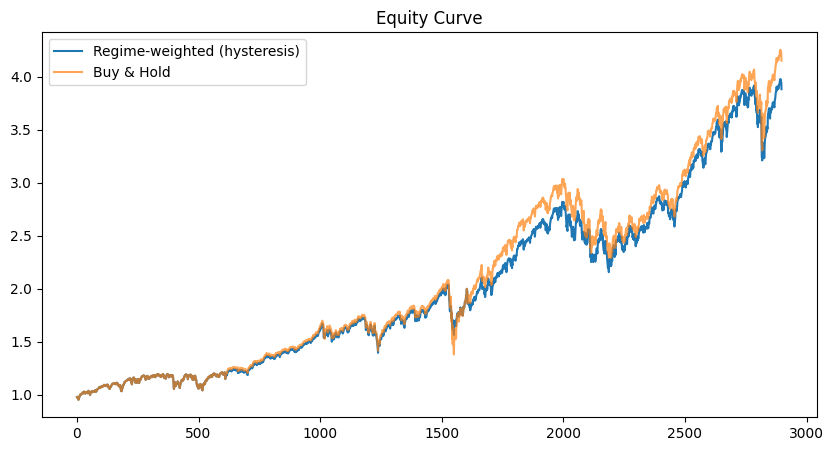

In [ ]:
# Choose your feature matrix X and targets
# Example:
# X = spy[feature_cols]
# y_rv = spy["RV5_fwd_ann"]
# base_rv = spy["RV20_trail"]
# ret_fwd = spy["ret_fwd_1d"]

loss_m, loss_b, loss_d, auc_m, auc_b, auc_d, stats = walk_forward_reg_oof(
    X, spy["RV5_fwd_ann"], spy["RV20_trail"], spy["ret_fwd_1d"],
    train_size=1000, test_size=126,
    alpha=1.0, high_q=0.8,
    n_splits=5, min_train_size=200
)

print("windows (evaluated):", len(loss_m))
print("total windows:", stats["total_windows"])
print("skipped windows:", stats["skipped_windows"])

tp = np.array(stats["train_prevalences"])
mc = np.array(stats["mask_counts"])
print("y_train prevalence: mean", tp.mean(), "min", tp.min(), "max", tp.max())
print("mask count: mean", mc.mean(), "min", mc.min(), "max", mc.max())

print("logloss: model", loss_m.mean(), "baseline", loss_b.mean(), "dumb", loss_d.mean())
print("auc: model", auc_m.mean(), "baseline", auc_b.mean(), "dumb", auc_d.mean())

# concatenate returns and plot equity curves
strat = np.concatenate(stats["strat_ret_list"])
bh = np.concatenate(stats["bh_ret_list"])

eq_strat = np.cumprod(1 + strat)   # W(t+1) = Wt + rtWt = Wt(1+rt)
eq_bh = np.cumprod(1 + bh)

def sharpe(x, ann=252):            #Sharpe ratio measures how much return you earn per unit of risk
    mu = np.mean(x) * ann       # mu = annualised mean return
    sd = np.std(x, ddof=1) * np.sqrt(ann)  # Annualised volatility, ddof is delta degree of freedom ( how many degrees of freedom to substract when computing variance/std)
    return mu / sd if sd > 0 else np.nan

def max_drawdown(eq):
    peak = np.maximum.accumulate(eq)
    return np.min(eq / peak - 1)

def avg_turnover(w_list):
    w = np.concatenate(w_list)
    stats_raw = np.mean(np.abs(np.diff(w)))
    return stats_raw

turnover_raw = avg_turnover(stats["w_list"])        # Turnover measures how aggrssively exposure changes


print("Sharpe strat:", sharpe(strat))
print("Sharpe buy&hold:", sharpe(bh))
print("MDD strat:", max_drawdown(eq_strat))
print("MDD buy&hold:", max_drawdown(eq_bh))

print("Turnover raw:", turnover_raw)


plt.figure(figsize=(10,5))
plt.plot(eq_strat, label="Regime-weighted (hysteresis)")
plt.plot(eq_bh, label="Buy & Hold", alpha=0.7)
plt.title("Equity Curve")
plt.legend()
plt.show()


Across 23 walk-forward windows with no skipped periods, the volatility-regime model shows strong and consistent performance. The model achieves substantially better probabilistic accuracy than both the baseline and a dumb constant-probability benchmark, with a mean log loss of 0.36 versus 0.44 (baseline) and 0.51 (dumb), and a high AUC of 0.93 compared to 0.78 and 0.50 respectively. When used as a risk-control overlay on returns, the strategy improves risk-adjusted performance: the regime-weighted strategy delivers a higher Sharpe ratio (0.85 vs 0.79 for buy-and-hold) while materially reducing maximum drawdown (-23.5% vs -33.7%). These results indicate that the model adds value not by predicting returns directly, but by dynamically controlling exposure during high-risk volatility regimes, leading to smoother equity curves and improved downside protection.

Next steps will be to test out some methods to improve Sharpe and drawdown. This includes calibrating the probabilities and using ccontinous sizing intead odf buckets.

### **Calibrated walk-forward**

In [ ]:
def fit_platt_calibrator(p_raw, y):
    cal = LogisticRegression(max_iter=2000)
    cal.fit(p_raw.reshape(-1, 1), y)
    return cal


In [ ]:
from sklearn.metrics import brier_score_loss

def walk_forward_reg_platt_cal(
    X, y_rv, base_rv, ret_fwd,
    train_size=1000, test_size=126,
    alpha=1.0, high_q=0.8,
    min_train_size=200, n_splits=5
):
    # align & drop missing
    df = X.copy()
    df["_y_rv"] = y_rv
    df["_base_rv"] = base_rv
    df["_ret_fwd"] = ret_fwd
    df = df.dropna()

    X = df.drop(columns=["_y_rv", "_base_rv", "_ret_fwd"])
    y_rv = df["_y_rv"]
    base_rv = df["_base_rv"]
    ret_fwd = df["_ret_fwd"]

    n = len(X)

    # diagnostics
    total_windows = 0
    skipped_windows = 0
    train_prevalences = []
    mask_counts = []

    # per-window arrays for ROC / plotting
    y_test_list = []
    model_prob_list = []
    test_index_list = []
    base_prob_list = []
    dumb_prob_list = []

    # tradable overlay series
    all_strat_ret = []
    all_bh_ret = []
    all_w = []

    brier_list = []

    # metrics
    model_losses, base_losses, dumb_losses = [], [], []
    model_aucs, base_aucs, dumb_aucs = [], [], []

    reg_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])
    base_reg_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])

    start = 0
    while start + train_size + test_size < n:
        total_windows += 1

        tr = slice(start, start + train_size)
        te = slice(start + train_size, start + train_size + test_size)

        X_train, X_test = X.iloc[tr], X.iloc[te]
        y_rv_train, y_rv_test = y_rv.iloc[tr], y_rv.iloc[te]
        base_rv_train, base_rv_test = base_rv.iloc[tr], base_rv.iloc[te]
        ret_test = ret_fwd.iloc[te].to_numpy()

        # regime labels defined from TRAIN ONLY
        threshold = y_rv_train.quantile(high_q)
        y_train = (y_rv_train > threshold).astype(int)
        y_test = (y_rv_test > threshold).astype(int)

        if y_train.nunique() < 2:
            skipped_windows += 1
            start += test_size
            continue

        train_prevalences.append(float(y_train.mean()))



       # --- split train into FIT and CAL (time-ordered) ---
        cal_frac = 0.2
        cal_size = int(cal_frac * train_size)
        fit_end = train_size - cal_size

        X_fit = X_train.iloc[:fit_end]
        X_cal = X_train.iloc[fit_end:]

        y_rv_fit = y_rv_train.iloc[:fit_end]
        y_rv_cal = y_rv_train.iloc[fit_end:]

        y_fit = y_train.iloc[:fit_end]
        y_cal = y_train.iloc[fit_end:]

        # --- OOF on FIT only (leakage-safe stacking) ---
        model_oof, model_mask = _ts_oof_preds(
            reg_pipeline, X_fit, y_rv_fit,
            n_splits=n_splits, min_train_size=min_train_size
        )

        if model_mask.sum() < 50 or y_fit.iloc[model_mask].nunique() < 2:
            skipped_windows += 1
            start += test_size
            continue

        clf = LogisticRegression(max_iter=2000)
        clf.fit(model_oof[model_mask].reshape(-1, 1), y_fit.iloc[model_mask])

        # --- refit ridge on FIT, produce RAW probs on CAL ---
        reg_pipeline.fit(X_fit, y_rv_fit)
        rv_cal_pred = reg_pipeline.predict(X_cal).reshape(-1, 1)
        p_cal_raw = clf.predict_proba(rv_cal_pred)[:, 1]

        # --- fit calibrator on CAL ---
        # Make sure y_cal has both classes; otherwise skip calibration and use raw
        if y_cal.nunique() < 2:
            cal_model = None
        else:
            cal_model = fit_platt_calibrator(p_cal_raw, y_cal.to_numpy())

        # --- produce RAW probs on TEST ---
        rv_test_pred = reg_pipeline.predict(X_test).reshape(-1, 1)
        p_test_raw = clf.predict_proba(rv_test_pred)[:, 1]

        # --- CALIBRATE probs on TEST ---
        if cal_model is None:
            clf_prob = p_test_raw
        else:
            clf_prob = cal_model.predict_proba(p_test_raw.reshape(-1, 1))[:, 1]

        brier = brier_score_loss(y_test, clf_prob)
        brier_list.append(brier)



        # ----- baseline: only RV20_trail feature -----
        base_X_train = base_rv_train.to_frame("baseline")
        base_X_test  = base_rv_test.to_frame("baseline")

        base_oof, base_mask = _ts_oof_preds(
            base_reg_pipeline, base_X_train, y_rv_train,
            n_splits=n_splits, min_train_size=min_train_size
        )

        if base_mask.sum() >= 50 and y_train.iloc[base_mask].nunique() > 1:
            base_clf = LogisticRegression(max_iter=2000)
            base_clf.fit(base_oof[base_mask].reshape(-1, 1), y_train.iloc[base_mask])

            base_reg_pipeline.fit(base_X_train, y_rv_train)
            base_pred = base_reg_pipeline.predict(base_X_test).reshape(-1, 1)
            base_prob = base_clf.predict_proba(base_pred)[:, 1]
        else:
            base_prob = np.full(len(y_test), float(y_train.mean()), dtype=float)

        # ----- dumb: constant p0 -----
        p0 = float(y_train.mean())
        dumb_prob = np.full(len(y_test), p0, dtype=float)

        # numeric safety for logloss
        eps = 1e-12
        clf_prob = np.clip(clf_prob, eps, 1-eps)
        base_prob = np.clip(base_prob, eps, 1-eps)
        dumb_prob = np.clip(dumb_prob, eps, 1-eps)

        # metrics
        model_losses.append(log_loss(y_test, clf_prob, labels=[0, 1]))
        base_losses.append(log_loss(y_test, base_prob, labels=[0, 1]))
        dumb_losses.append(log_loss(y_test, dumb_prob, labels=[0, 1]))

        if y_test.nunique() > 1:
            model_aucs.append(roc_auc_score(y_test, clf_prob))
            base_aucs.append(roc_auc_score(y_test, base_prob))
            dumb_aucs.append(roc_auc_score(y_test, dumb_prob))

        # store per-window arrays for ROC plots
        y_test_list.append(y_test.to_numpy())
        model_prob_list.append(clf_prob.copy())
        base_prob_list.append(base_prob.copy())
        test_index_list.append(X_test.index.copy())
        dumb_prob_list.append(dumb_prob.copy())

        mask_counts.append(int(model_mask.sum()))

        # ----- tradable overlay using hysteresis -----
        w = prob_to_weight_hysteresis(clf_prob, exit_hi=0.8, enter_lo=0.5, w_mid=0.5)
        strat_ret = w * ret_test

        all_w.append(w)
        all_strat_ret.append(strat_ret)
        all_bh_ret.append(ret_test)

        start += test_size

    stats = {
        "total_windows": total_windows,
        "skipped_windows": skipped_windows,
        "mask_counts": mask_counts,
        "train_prevalences": train_prevalences,
        "y_test_list": y_test_list,
        "model_prob_list": model_prob_list,
        "base_prob_list": base_prob_list,
        "test_index_list": test_index_list,
        "dumb_prob_list": dumb_prob_list,
        "w_list": all_w,
        "strat_ret_list": all_strat_ret,
        "bh_ret_list": all_bh_ret,
        "brier_list": brier_list,
    }

    return (
        np.array(model_losses), np.array(base_losses), np.array(dumb_losses),
        np.array(model_aucs), np.array(base_aucs), np.array(dumb_aucs),
        stats
    )




windows (evaluated): 23
total windows: 23
skipped windows: 0
y_train prevalence: mean 0.20000000000000007 min 0.2 max 0.2
mask count: mean 532.0 min 532 max 532
logloss: model 0.4855778828987032 baseline 0.4357681713570772 dumb 0.513031192045284
auc: model 0.9338916348795541 baseline 0.7844948750512718 dumb 0.5
Brier mean: 0.14755882715324728
Sharpe strat: 0.8950665656301466
Sharpe buy&hold: 0.7935961777701855
MDD strat: -0.23783569433580243
MDD buy&hold: -0.33717274003198405
Turnover calibrated: 0.005868139454608215


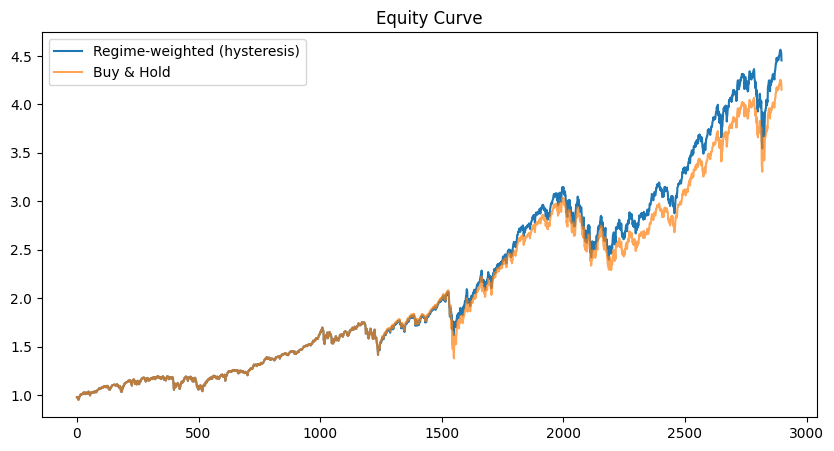

In [ ]:
# Choose your feature matrix X and targets
# Example:
# X = spy[feature_cols]
# y_rv = spy["RV5_fwd_ann"]
# base_rv = spy["RV20_trail"]
# ret_fwd = spy["ret_fwd_1d"]

loss_m, loss_b, loss_d, auc_m, auc_b, auc_d, stats = walk_forward_reg_platt_cal(
    X, spy["RV5_fwd_ann"], spy["RV20_trail"], spy["ret_fwd_1d"],
    train_size=1000, test_size=126,
    alpha=1.0, high_q=0.8,
    n_splits=5, min_train_size=200
)

print("windows (evaluated):", len(loss_m))
print("total windows:", stats["total_windows"])
print("skipped windows:", stats["skipped_windows"])

tp = np.array(stats["train_prevalences"])
mc = np.array(stats["mask_counts"])
print("y_train prevalence: mean", tp.mean(), "min", tp.min(), "max", tp.max())
print("mask count: mean", mc.mean(), "min", mc.min(), "max", mc.max())

print("logloss: model", loss_m.mean(), "baseline", loss_b.mean(), "dumb", loss_d.mean())
print("auc: model", auc_m.mean(), "baseline", auc_b.mean(), "dumb", auc_d.mean())

print("Brier mean:", np.mean(stats["brier_list"]))


# concatenate returns and plot equity curves
strat = np.concatenate(stats["strat_ret_list"])
bh = np.concatenate(stats["bh_ret_list"])

eq_strat = np.cumprod(1 + strat)   # W(t+1) = Wt + rtWt = Wt(1+rt)
eq_bh = np.cumprod(1 + bh)

def sharpe(x, ann=252):            #Sharpe ratio measures how much return you earn per unit of risk
    mu = np.mean(x) * ann       # mu = annualised mean return
    sd = np.std(x, ddof=1) * np.sqrt(ann)  # Annualised volatility, ddof is delta degree of freedom ( how many degrees of freedom to substract when computing variance/std)
    return mu / sd if sd > 0 else np.nan

def max_drawdown(eq):
    peak = np.maximum.accumulate(eq)
    return np.min(eq / peak - 1)

def avg_turnover(w_list):                     # Turnover measures how aggrssively exposure changes, Lower turnover - fewer abrupt flips - better risk efficiency
    w = np.concatenate(w_list)
    stats_cal = np.mean(np.abs(np.diff(w)))
    return stats_cal

turnover_cal = avg_turnover(stats["w_list"])


print("Sharpe strat:", sharpe(strat))
print("Sharpe buy&hold:", sharpe(bh))
print("MDD strat:", max_drawdown(eq_strat))
print("MDD buy&hold:", max_drawdown(eq_bh))

print("Turnover calibrated:", turnover_cal)

plt.figure(figsize=(10,5))
plt.plot(eq_strat, label="Regime-weighted (hysteresis)")
plt.plot(eq_bh, label="Buy & Hold", alpha=0.7)
plt.title("Equity Curve")
plt.legend()
plt.show()


After introducing Platt calibration within each walk-forward window, the model’s ranking ability (AUC ≈ 0.93) remained unchanged, as expected, while log loss increased from roughly 0.36 to 0.49 due to the probabilities becoming less extreme and more conservative. Despite the deterioration in log loss, the tradable overlay improved in risk-adjusted performance, with Sharpe rising from 0.85 to 0.90 and maximum drawdown remaining materially lower than buy-and-hold.
Over the historical sample, **the calibrated version will likely produce slightly higher cumulative return**, because Sharpe improved and turnover dropped- but the difference in total return may be modest. Given Sharpe improved without increasing drawdown, calibration likely improved both smoothness and compounding effficiency. The Brier score (~0.148) confirms reasonable probability calibration relative to a constant benchmark. This suggests that calibration reduced overconfidence and stabilized exposure decisions, improving trading efficiency even though pure probabilistic fit slightly worsened.
In the next steps, I decided to compute the compute te final equity instead of guessing

In [ ]:
loss_m, loss_b, loss_d, auc_m, auc_b, auc_d, stats = walk_forward_reg_oof(
    X, spy["RV5_fwd_ann"], spy["RV20_trail"], spy["ret_fwd_1d"],
    train_size=1000, test_size=126,
    alpha=1.0, high_q=0.8,
    n_splits=5, min_train_size=200
)

print("windows (evaluated):", len(loss_m))
print("total windows:", stats["total_windows"])
print("skipped windows:", stats["skipped_windows"])

tp = np.array(stats["train_prevalences"])
mc = np.array(stats["mask_counts"])
print("y_train prevalence: mean", tp.mean(), "min", tp.min(), "max", tp.max())
print("mask count: mean", mc.mean(), "min", mc.min(), "max", mc.max())

print("logloss: model", loss_m.mean(), "baseline", loss_b.mean(), "dumb", loss_d.mean())
print("auc: model", auc_m.mean(), "baseline", auc_b.mean(), "dumb", auc_d.mean())

# concatenate returns and plot equity curves
strat = np.concatenate(stats["strat_ret_list"])
bh = np.concatenate(stats["bh_ret_list"])

eq_strat = np.cumprod(1 + strat)   # W(t+1) = Wt + rtWt = Wt(1+rt)
eq_bh = np.cumprod(1 + bh)

def sharpe(x, ann=252):            #Sharpe ratio measures how much return you earn per unit of risk
    mu = np.mean(x) * ann       # mu = annualised mean return
    sd = np.std(x, ddof=1) * np.sqrt(ann)  # Annualised volatility, ddof is delta degree of freedom ( how many degrees of freedom to substract when computing variance/std)
    return mu / sd if sd > 0 else np.nan

def max_drawdown(eq):
    peak = np.maximum.accumulate(eq)
    return np.min(eq / peak - 1)

def avg_turnover(w_list):
    w = np.concatenate(w_list)
    stats_raw = np.mean(np.abs(np.diff(w)))
    return stats_raw

turnover_raw = avg_turnover(stats["w_list"])        # Turnover measures how aggrssively exposure changes

eq_raw = np.cumprod(1 + np.concatenate(stats["strat_ret_list"]))

# CAGR = compound annual growth rate

print("Sharpe strat:", sharpe(strat))
print("Sharpe buy&hold:", sharpe(bh))
print("MDD strat:", max_drawdown(eq_strat))
print("MDD buy&hold:", max_drawdown(eq_bh))

print("Turnover raw:", turnover_raw)
print("Final return RAW:", eq_raw[-1] - 1)



windows (evaluated): 23
total windows: 23
skipped windows: 0
y_train prevalence: mean 0.20000000000000007 min 0.2 max 0.2
mask count: mean 664.0 min 664 max 664
logloss: model 0.3595804719025796 baseline 0.4357681713570772 dumb 0.513031192045284
auc: model 0.933744092029004 baseline 0.7844948750512718 dumb 0.5
Sharpe strat: 0.8478175087355415
Sharpe buy&hold: 0.7935961777701855
MDD strat: -0.23512393593684522
MDD buy&hold: -0.33717274003198405
Turnover raw: 0.009665170866413532
Final return RAW: 2.8828633593613833


In [ ]:
loss_m, loss_b, loss_d, auc_m, auc_b, auc_d, stats = walk_forward_reg_platt_cal(
    X, spy["RV5_fwd_ann"], spy["RV20_trail"], spy["ret_fwd_1d"],
    train_size=1000, test_size=126,
    alpha=1.0, high_q=0.8,
    n_splits=5, min_train_size=200
)

print("windows (evaluated):", len(loss_m))
print("total windows:", stats["total_windows"])
print("skipped windows:", stats["skipped_windows"])

tp = np.array(stats["train_prevalences"])
mc = np.array(stats["mask_counts"])
print("y_train prevalence: mean", tp.mean(), "min", tp.min(), "max", tp.max())
print("mask count: mean", mc.mean(), "min", mc.min(), "max", mc.max())

print("logloss: model", loss_m.mean(), "baseline", loss_b.mean(), "dumb", loss_d.mean())
print("auc: model", auc_m.mean(), "baseline", auc_b.mean(), "dumb", auc_d.mean())

print("Brier mean:", np.mean(stats["brier_list"]))


# concatenate returns and plot equity curves
strat = np.concatenate(stats["strat_ret_list"])
bh = np.concatenate(stats["bh_ret_list"])

eq_strat = np.cumprod(1 + strat)   # W(t+1) = Wt + rtWt = Wt(1+rt)
eq_bh = np.cumprod(1 + bh)

def sharpe(x, ann=252):            #Sharpe ratio measures how much return you earn per unit of risk
    mu = np.mean(x) * ann       # mu = annualised mean return
    sd = np.std(x, ddof=1) * np.sqrt(ann)  # Annualised volatility, ddof is delta degree of freedom ( how many degrees of freedom to substract when computing variance/std)
    return mu / sd if sd > 0 else np.nan

def max_drawdown(eq):
    peak = np.maximum.accumulate(eq)
    return np.min(eq / peak - 1)

def avg_turnover(w_list):                     # Turnover measures how aggrssively exposure changes, Lower turnover - fewer abrupt flips - better risk efficiency
    w = np.concatenate(w_list)
    stats_cal = np.mean(np.abs(np.diff(w)))
    return stats_cal

turnover_cal = avg_turnover(stats["w_list"])
eq_cal = np.cumprod(1 + np.concatenate(stats["strat_ret_list"]))




print("Sharpe strat:", sharpe(strat))
print("Sharpe buy&hold:", sharpe(bh))
print("MDD strat:", max_drawdown(eq_strat))
print("MDD buy&hold:", max_drawdown(eq_bh))

print("Turnover calibrated:", turnover_cal)
print("Final return CAL:", eq_cal[-1] - 1)



windows (evaluated): 23
total windows: 23
skipped windows: 0
y_train prevalence: mean 0.20000000000000007 min 0.2 max 0.2
mask count: mean 532.0 min 532 max 532
logloss: model 0.4855778828987032 baseline 0.4357681713570772 dumb 0.513031192045284
auc: model 0.9338916348795541 baseline 0.7844948750512718 dumb 0.5
Brier mean: 0.14755882715324728
Sharpe strat: 0.8950665656301466
Sharpe buy&hold: 0.7935961777701855
MDD strat: -0.23783569433580243
MDD buy&hold: -0.33717274003198405
Turnover calibrated: 0.005868139454608215
Final return CAL: 3.4543924366417302


The calibrated model has a better total return compared to the raw model. Even though the logg loss worsened from 0.36 to 0.49, the trading performance improved. CAGR ( Compound Annual growth Rate) answers if my strategy grew at aconstant yearly rate, what rate would give the final value? CAGR = (final value/initial value**(1/T) - 1) or (Wt/W0)**(1/T) - 1

## **Probability Distribution Histogram**

N: 2898
prevalance: 0.20910973084886128
p_hat min/mean/max: 0.005010732527271995 0.17563045052508608 0.8211571187233374


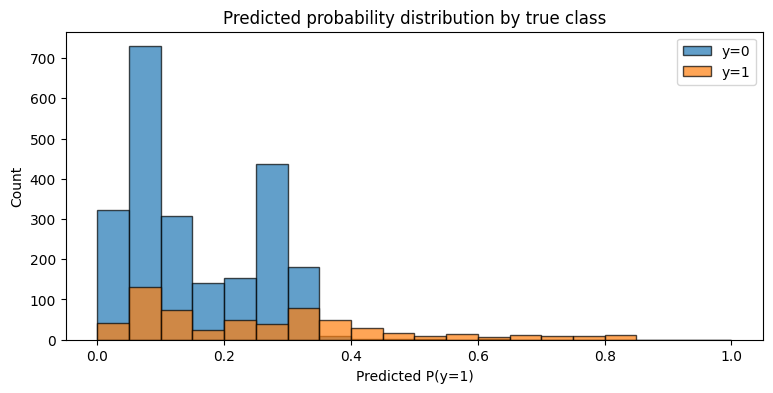

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_true = np.concatenate(stats["y_test_list"]).astype(int)
p_hat = np.concatenate(stats["model_prob_list"]).astype(float)

print("N:", len(y_true))
print("prevalance:", y_true.mean())
print("p_hat min/mean/max:", p_hat.min(), p_hat.mean(), p_hat.max())

bins = np.linspace(0, 1, 21)

plt.figure(figsize=(9,4))
plt.hist(p_hat[y_true==0], bins=bins, alpha=0.7, edgecolor='k', label="y=0")
plt.hist(p_hat[y_true==1], bins=bins, alpha=0.7, edgecolor='k', label="y=1")
plt.title("Predicted probability distribution by true class")
plt.xlabel("Predicted P(y=1)")
plt.ylabel("Count")
plt.legend()
plt.show()

The chart shows the distribution of the model’s predicted probabilities for class 1, separated by true outcomes ( the bars depicts the true outcome), illustrating that higher probabilities are more frequently associated with actual positive events, indicating effective ranking ability, the model is often right when its confident in predicting y=1.
classification accuracy tells whether the model is correct and probability histogram tells how the model thinks (signal density map).
***Note: when p_hat = 0.35, model believes 35% chance that y=1, it does not mean the model predicted class 1.***



## **Probability Regime Map:** / **Bin Hit Rate**

This answers when the model predicts x%, how often is it actuall correct?
This bin hit rate translate model behavior into trading threshold design. this is strategy engineering not model validation. Strategy engineering ask - At what probability level does taking risk make economic sense or where is expected return attractive relative to costs and drawdown?

Observations = How many predictions fell into that probability range.
Example:

If between 0.30–0.40 the model produced 220 predictions,

Then: Observations = 220

It tells you sample size.

Actual event rate = Among those observations in that bin, how often did y=1 actually occur?

Mathematically:

If in the 0.30–0.40 bin:

220 total observations

88 of them had y=1

Then:

Actual event rate = 88 / 220 = 0.40

In [ ]:
n_bins = 5
bins = np.linspace(0, 1, n_bins+1)
bin_id = np.digitize(p_hat, bins) - 1
for i in range(len(bins)-1):
    mask = bin_id == i
    if mask.sum() > 0:
      hit_rate = y_true[mask].mean()
      avg_prob = p_hat[mask].mean()
      print(f"Bin{bins[i]:.1f} - {bins[i+1]:.1f} | "
      f"Avg Prob: {avg_prob:.3f} | "
      f"Hit Rate: {hit_rate:.3f} | "
      f"N: {mask.sum()}")

print(f"Len y_true: {len(y_true)}")
print(f"Len p_hat: {len(p_hat)}")
print(f"y_true_mean: {y_true.mean()}")

corr = np.corrcoef(p_hat, y_true)[0,1]
corr

Bin0.0 - 0.2 | Avg Prob: 0.087 | Hit Rate: 0.153 | N: 1773
Bin0.2 - 0.4 | Avg Prob: 0.282 | Hit Rate: 0.216 | N: 998
Bin0.4 - 0.6 | Avg Prob: 0.475 | Hit Rate: 0.908 | N: 76
Bin0.6 - 0.8 | Avg Prob: 0.700 | Hit Rate: 0.974 | N: 39
Bin0.8 - 1.0 | Avg Prob: 0.816 | Hit Rate: 1.000 | N: 12
Len y_true: 2898
Len p_hat: 2898
y_true_mean: 0.20910973084886128


np.float64(0.3384786789064989)

The model demonstrates strong regime separation: predicted probabilities are highly skewed toward the low-volatility class, but once probabilities exceed ~0.4, the realized hit rate increases sharply (in other words model is saying its almost always corect when exceeds 0.4), indicating that high-confidence predictions correspond to concentrated high-volatility regimes, albeit with smaller sample sizes in the upper bins.

## **Quantile Stability Check**

In [ ]:
import numpy as np
n_bins = 5

quantile = np.quantile(p_hat, np.linspace(0, 1, n_bins+1))

quantile = np.unique(quantile)

bin_id = np.digitize(p_hat, quantile, right=True) - 1
for i in range(len(quantile)-1):
    mask = bin_id == i
    if mask.sum() > 0:
      hit_rate = y_true[mask].mean()
      avg_prob = p_hat[mask].mean()
      print(f"Bin {quantile[i]:.3f} - {quantile[i+1]:.3f} | "
      f"Avg Prob: {avg_prob:.3f} | "
      f"Hit Rate: {hit_rate:.3f} | "
      f"N: {mask.sum()}")


Bin 0.005 - 0.066 | Avg Prob: 0.039 | Hit Rate: 0.104 | N: 579
Bin 0.066 - 0.096 | Avg Prob: 0.082 | Hit Rate: 0.173 | N: 579
Bin 0.096 - 0.192 | Avg Prob: 0.133 | Hit Rate: 0.181 | N: 580
Bin 0.192 - 0.281 | Avg Prob: 0.249 | Hit Rate: 0.135 | N: 579
Bin 0.281 - 0.821 | Avg Prob: 0.375 | Hit Rate: 0.453 | N: 580


Quantile stabilty check confirms ranking power is real and the extreme tail explosion witness in previous bin hit rate was partly small-sample concentration. Using equal-frequency quantile bins, the model shows stable regime separation: the lowest probability quantile exhibits roughly half the base-rate high-vol frequency, while the top quantile more than doubles the base-rate risk, confirming genuine ranking power despite imperfect mid-quantile calibration.
In the 4th bin the bin hit rate is 0.135. The model's prababilities are not perfectly smooth or monotonic. This is fine because the extremes are behaving correctly and the signal is concentrated where it matters.

## **Forward Return per quantile and RV magnitude per quantile.**

In [ ]:
import numpy as np

test_index = np.concatenate(stats["test_index_list"])
y_true = np.concatenate(stats["y_test_list"]).astype(int)
p_hat = np.concatenate(stats["model_prob_list"]).astype(float)

ret_fwd_1d = spy.loc[test_index, "ret_fwd_1d"].to_numpy(dtype=float)
rv5_fwd = spy.loc[test_index, "RV5_fwd"].to_numpy(dtype=float)

assert len(ret_fwd_1d) == len(p_hat) == len(y_true) == len(rv5_fwd)

valid = np.isfinite(ret_fwd_1d) & np.isfinite(p_hat) & np.isfinite(rv5_fwd) & np.isfinite(y_true)
ret_fwd_1d = ret_fwd_1d[valid]
p_hat = p_hat[valid]
test_index = test_index[valid]
y_true = y_true[valid]
rv5_fwd = rv5_fwd[valid]

stats["test_index"] = test_index
stats["ret_fwd_1d_aligned"] = ret_fwd_1d
stats["rv5_fwd_aligned"] = rv5_fwd

In [ ]:
n_bins = 5
edges = np.quantile(p_hat, np.linspace(0, 1, n_bins+1))
edges = np.unique(edges)

bin_id = np.digitize(p_hat, edges[1:-1])

for i in range(len(edges) - 1):
  m = bin_id == i
  if m.sum() > 0:
    print(
        f"QBin {edges[i]:.3f}-{edges[i+1]:.3f} | "
        f"N: {m.sum():4d} | "
        f"Avg Prob: {p_hat[m].mean():.3f} | "
        f"Hit Rate: {y_true[m].mean():.3f} | "
        f"Avg Ret_fwd_1d: {ret_fwd_1d[m].mean():.5f} | "
        f"Avg RV5_fwd: {rv5_fwd[m].mean():.5f} | "
        )


QBin 0.005-0.066 | N:  580 | Avg Prob: 0.039 | Hit Rate: 0.103 | Avg Ret_fwd_1d: 0.00056 | Avg RV5_fwd: 0.00631 | 
QBin 0.066-0.096 | N:  579 | Avg Prob: 0.082 | Hit Rate: 0.173 | Avg Ret_fwd_1d: 0.00042 | Avg RV5_fwd: 0.00758 | 
QBin 0.096-0.192 | N:  580 | Avg Prob: 0.133 | Hit Rate: 0.181 | Avg Ret_fwd_1d: 0.00007 | Avg RV5_fwd: 0.00863 | 
QBin 0.192-0.281 | N:  579 | Avg Prob: 0.249 | Hit Rate: 0.135 | Avg Ret_fwd_1d: 0.00101 | Avg RV5_fwd: 0.00723 | 
QBin 0.281-0.821 | N:  580 | Avg Prob: 0.375 | Hit Rate: 0.453 | Avg Ret_fwd_1d: 0.00071 | Avg RV5_fwd: 0.01351 | 


The model demonstrates meaningful economic regime separation: while average forward returns remain broadly similar across quantiles, realized volatility more than doubles in the highest probability bin relative to the lowest, indicating that the signal captures risk intensity rather than directional alpha and is therefore structurally suited for volatility-based exposure scaling.

## **Sharpe per Quantile**

In [ ]:
n_bins = 5
edges = np.quantile(p_hat, np.linspace(0, 1, n_bins+1))
edges = np.unique(edges)

bin_id = np.digitize(p_hat, edges[1:-1])

for i in range (len(edges) - 1):
    m = bin_id == i
    if m.sum() > 0:
      mu = ret_fwd_1d[m].mean()
      sigma = ret_fwd_1d[m].std()
      sharpe = mu / sigma if sigma > 0 else np.nan

      print(
          f"Q Bin {edges[i]:.3f}-{edges[i+1]:.3f} | "
          f"N: {m.sum():4d} | "
          f"Mean: {mu:.6f} | "
          f"Std: {sigma:.6f} | "
          f"Sharpe (daily): {sharpe:.3f} | "
          f"Sharpe (annum): {sharpe * np.sqrt(252):.3f}"
          )


Q Bin 0.005-0.066 | N:  580 | Mean: 0.000557 | Std: 0.007941 | Sharpe (daily): 0.070 | Sharpe (annum): 1.114
Q Bin 0.066-0.096 | N:  579 | Mean: 0.000421 | Std: 0.009251 | Sharpe (daily): 0.046 | Sharpe (annum): 0.723
Q Bin 0.096-0.192 | N:  580 | Mean: 0.000067 | Std: 0.011143 | Sharpe (daily): 0.006 | Sharpe (annum): 0.096
Q Bin 0.192-0.281 | N:  579 | Mean: 0.001006 | Std: 0.009073 | Sharpe (daily): 0.111 | Sharpe (annum): 1.760
Q Bin 0.281-0.821 | N:  580 | Mean: 0.000712 | Std: 0.015969 | Sharpe (daily): 0.045 | Sharpe (annum): 0.708


Risk-adjusted performance varies meaningfully across volatility regimes, with the lowest probability quantile exhibiting strong Sharpe (1.11), the highest volatility quantile showing materially lower Sharpe (0.71), and a mid-high probability bin unexpectedly delivering the strongest Sharpe (1.76), indicating that while elevated volatility generally reduces return efficiency, the relationship between predicted risk and performance is nonlinear rather than strictly monotonic.

## **Performance Metrics**

In [ ]:
import numpy as np

exposure = 1 - p_hat
strategy_ret = exposure * ret_fwd_1d
bh_ret = ret_fwd_1d.copy()


In [ ]:
def compute_metrics(r):
  r = np.asarray(r)
  mu = r.mean()
  sigma = r.std()
  sharpe_daily = mu / sigma if sigma > 0 else np.nan
  sharpe_annum = sharpe_daily * np.sqrt(252)

  #CAGR

  eq = np.cumprod(1 + r)
  years = len(r) / 252
  cagr = eq[-1]**(1/years) - 1

  #max drawdown

  peak = np.maximum.accumulate(eq)
  dd = (eq - peak) / peak
  mdd = dd.min()

  return {
      "mu": mu,
      "sigma": sigma,
      "sharpe_annum": sharpe_annum,
      "CAGR": cagr,
      "Maximum Draw Down": mdd,
  }

metrics_strategy  = compute_metrics(strategy_ret)
metrics_bh = compute_metrics(bh_ret)

print("Strategy Metrics (Vol Scaling):")
for k, v in metrics_strategy.items():
    print(f"{k}: {v:.4f}")

print("\nBuy & Hold Metrics:")
for k, v in metrics_bh.items():
    print(f"{k}: {v:.4f}")

Strategy Metrics (Vol Scaling):
mu: 0.0004
sigma: 0.0081
sharpe_annum: 0.8624
CAGR: 0.1082
Maximum Draw Down: -0.2067

Buy & Hold Metrics:
mu: 0.0006
sigma: 0.0111
sharpe_annum: 0.7937
CAGR: 0.1318
Maximum Draw Down: -0.3372


Continuous volatility-based exposure scaling meaningfully reduced portfolio volatility and maximum drawdown while improving Sharpe ratio relative to buy-and-hold, demonstrating that the model adds genuine risk-management value despite a modest reduction in raw CAGR. This lower volatility and higher sharpe can be aimed for  **volatility targeting or volatility normalization** (increase leverage until volatility matches buy & hold again).

## **Volatility Targeting**

In [ ]:
sigma_strategy = strategy_ret.std()
sigma_bh = bh_ret.std()

lambda_vol = sigma_bh / sigma_strategy
print("Volatility Scaling factor (lambda):", lambda_vol)

strategy_ret_vol_targeted = strategy_ret * lambda_vol

metrics_strategy_vol_targeted = compute_metrics(strategy_ret_vol_targeted)

print("Vol Targeted Strategy:")
for k, v in metrics_strategy_vol_targeted.items():
    print(f"{k}: {v:.4f}")

Volatility Scaling factor (lambda): 1.3630592388986762
Vol Targeted Strategy:
mu: 0.0006
sigma: 0.0111
sharpe_annum: 0.8624
CAGR: 0.1455
Maximum Draw Down: -0.2750


After volatility normalization, the regime-based scaling strategy achieves higher Sharpe, higher CAGR, and lower maximum drawdown than buy-and-hold at identical risk, confirming genuine economic value in the volatility signal.

The volatility regime model should function as a probabilistic risk filter layered on top of directional alpha models, dynamically scaling exposure to improve risk-adjusted performance and reduce drawdowns without relying on return prediction.

## **Stress Test - Sub Period Analysis**

In [ ]:
import pandas as pd
df = pd.DataFrame({"Strategy": strategy_ret_vol_targeted, "Buy & Hold": bh_ret}, index=pd.to_datetime(test_index))


periods = {
    "2010-2015": ("2010-01-01", "2015-12-31"),
    "2016-2019": ("2016-01-01", "2019-12-31"),
    "2020-2022": ("2020-01-01", "2022-12-31"),
    "2023-now": ("2023-01-01", "2026-12-31")
}

for name, (start, end) in periods.items():
    sub = df.loc[start:end]

    if len(sub) < 50:
      continue

    print(f"\n{name}")

    m_strat = compute_metrics(sub["Strategy"].values)
    m_bh = compute_metrics(sub["Buy & Hold"].values)

    print("Strategy Sharpe:", round(m_strat["sharpe_annum"], 3),
        "| CAGR:", round(m_strat["CAGR"], 3),
        "| MDD:", round(m_strat["Maximum Draw Down"], 3))

    print("Buy & Hold Sharpe:", round(m_bh["sharpe_annum"], 3),
        "| CAGR:", round(m_bh["CAGR"], 3),
        "| MDD:", round(m_bh["Maximum Draw Down"], 3))



2010-2015
Strategy Sharpe: 0.604 | CAGR: 0.09 | MDD: -0.14
Buy & Hold Sharpe: 0.578 | CAGR: 0.072 | MDD: -0.119

2016-2019
Strategy Sharpe: 1.087 | CAGR: 0.153 | MDD: -0.213
Buy & Hold Sharpe: 1.152 | CAGR: 0.15 | MDD: -0.193

2020-2022
Strategy Sharpe: 0.451 | CAGR: 0.075 | MDD: -0.275
Buy & Hold Sharpe: 0.402 | CAGR: 0.071 | MDD: -0.337

2023-now
Strategy Sharpe: 1.348 | CAGR: 0.268 | MDD: -0.226
Buy & Hold Sharpe: 1.364 | CAGR: 0.227 | MDD: -0.188


Subperiod analysis suggests the volatility overlay behaves like risk insurance—delivering its clearest gains during turbulent regimes (notably reducing 2020–2022 drawdown and improving Sharpe), while providing mixed or near-neutral impact in calmer bull-market periods.

## **3 Year - Rolling Sharpe Function**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

windows = 252 * 3

df_roll = pd.DataFrame({"Strategy": strategy_ret_vol_targeted,
                        "BuyHold": bh_ret
                        }, index=pd.to_datetime(test_index))

def rolling_sharpe(r, windows):
  mu = r.rolling(windows).mean()
  sigma = r.rolling(windows).std()
  sharpe = (mu / sigma) * np.sqrt(252)
  return sharpe

df_roll["Sharpe_Strategy"] = rolling_sharpe(df_roll["Strategy"], windows)
df_roll["Sharpe_BuyHold"] = rolling_sharpe(df_roll["BuyHold"], windows)



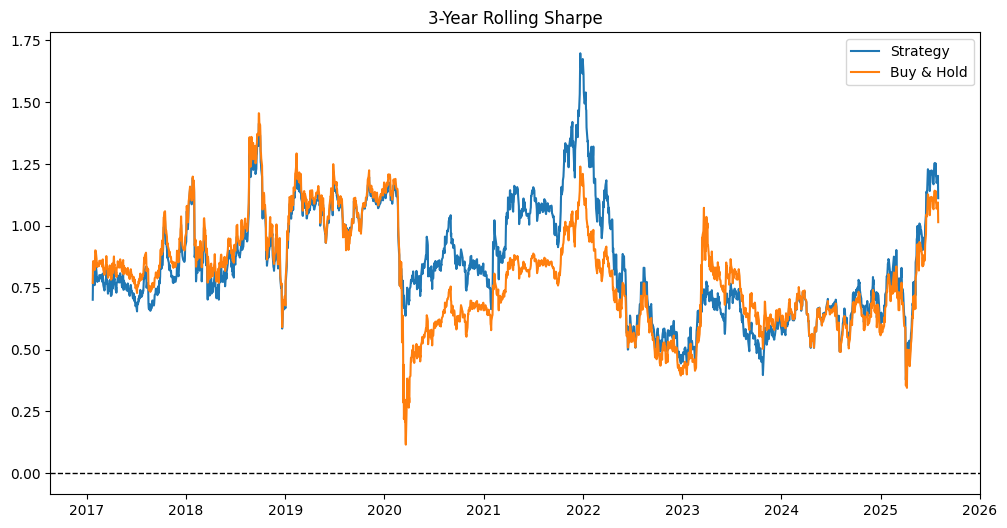

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df_roll.index, df_roll["Sharpe_Strategy"], label="Strategy")
plt.plot(df_roll.index, df_roll["Sharpe_BuyHold"], label="Buy & Hold")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend()
plt.title("3-Year Rolling Sharpe")
plt.show()

## **Historical Validation (2000 - 2026) with GFC Stress Test**

/tmp/ipython-input-394/2043810575.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="2000-01-01", progress=False)


Target mean (ann RV): 0.15438521773157304
Baseline mean (RV20): 0.1629045723824422
N: 6557
Windows implied: 44
First date kept: 2000-02-01 00:00:00
Last date kept: 2026-02-26 00:00:00
            RV5_trail  RV20_trail  VolRatio
Date                                       
2000-02-01   0.343967    0.344225  0.999250
2000-02-02   0.338801    0.313987  1.079028
2000-02-03   0.349585    0.318134  1.098861
2000-02-04   0.194799    0.312252  0.623852
2000-02-07   0.128811    0.231221  0.557089
Any NaNs: False
2000-02-01 00:00:00 2026-02-26 00:00:00
windows (evaluated): 44
total windows: 44
skipped windows: 0
y_train prevalence: mean 0.19999999999999993 min 0.2 max 0.2
mask count: mean 532.0 min 532 max 532
logloss: model 0.3969165577500445 baseline 0.37844311172264217 dumb 0.5014526465390362
auc: model 0.9294202427360355 baseline 0.7872716162901051 dumb 0.5
Brier mean: 0.12005256026013215
Sharpe strat: 0.7600204626667425
Sharpe buy&hold: 0.6288114317894086
MDD strat: -0.37736635718421874
MDD 

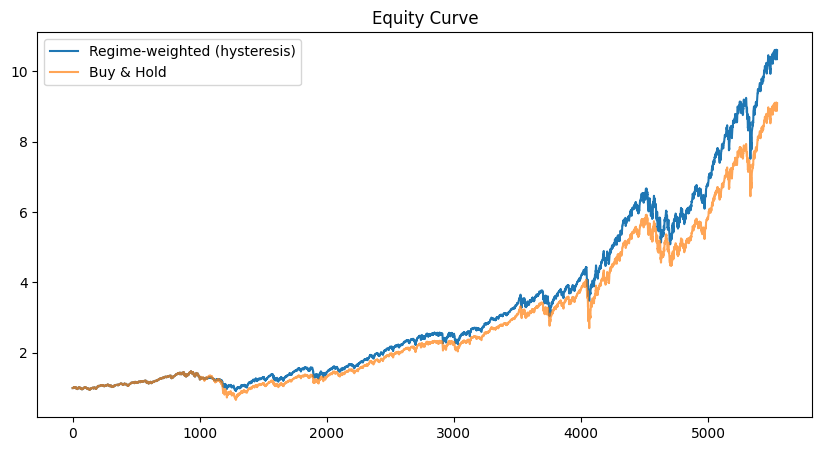

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import log_loss, roc_auc_score


# If you already have `spy` loaded from earlier work, you can skip the download part.
import yfinance as yf

spy = yf.download("SPY", start="2000-01-01", progress=False)
spy = spy[["Close"]].copy()

# --- Returns ---
spy["ret_1d"] = spy["Close"].pct_change()

spy["ret_fwd_1d"] = spy["ret_1d"].shift(-1)
# --- FUTURE 5-day realized volatility (target) ---
# Use returns from t+1..t+5 (forward-looking). This avoids leakage.
# We compute forward RV by shifting returns up by 1 and taking a rolling std over 5 days.
spy["RV5_fwd"] = spy["ret_1d"].shift(-1).rolling(5).std()

# Optional: annualize (common in practice). Comment out if you want raw 5-day vol.
spy["RV5_fwd_ann"] = spy["RV5_fwd"] * np.sqrt(252)

# --- TRAILING realized volatility (baseline feature) ---
spy["RV20_trail"] = spy["ret_1d"].rolling(20).std() * np.sqrt(252)
spy["RV5_trail"]  = spy["ret_1d"].rolling(5).std()  * np.sqrt(252)

# Drop rows with NaNs created by rolling windows and shifting
spy = spy.dropna().copy()

# Choose target
y = spy["RV5_fwd_ann"]  # or use "RV5_fwd" if you want non-annualized

# Baseline prediction: predict next-week vol as current trailing 20d vol
baseline_pred = spy["RV20_trail"]

print("Target mean (ann RV):", y.mean())
print("Baseline mean (RV20):", baseline_pred.mean())

N = len(spy)
train_size=1000
test_size=126

print("N:", N)
print("Windows implied:", (N - train_size)//test_size)

print("First date kept:", spy.index.min())
print("Last date kept:", spy.index.max())


# --- Feature matrix for Model 1 ---
X = pd.DataFrame({
    "RV5_trail": spy["RV5_trail"],
    "RV20_trail": spy["RV20_trail"],
})

X["VolRatio"] = X["RV5_trail"] / X["RV20_trail"]

# Target (already defined earlier)
y = spy["RV5_fwd_ann"]

print(X.head())
print("Any NaNs:", X.isna().any().any())

print(spy.index.min(), spy.index.max())

loss_m, loss_b, loss_d, auc_m, auc_b, auc_d, stats = walk_forward_reg_platt_cal(
    X, spy["RV5_fwd_ann"], spy["RV20_trail"], spy["ret_fwd_1d"],
    train_size=1000, test_size=126,
    alpha=1.0, high_q=0.8,
    n_splits=5, min_train_size=200
)

print("windows (evaluated):", len(loss_m))
print("total windows:", stats["total_windows"])
print("skipped windows:", stats["skipped_windows"])

tp = np.array(stats["train_prevalences"])
mc = np.array(stats["mask_counts"])
print("y_train prevalence: mean", tp.mean(), "min", tp.min(), "max", tp.max())
print("mask count: mean", mc.mean(), "min", mc.min(), "max", mc.max())

print("logloss: model", loss_m.mean(), "baseline", loss_b.mean(), "dumb", loss_d.mean())
print("auc: model", auc_m.mean(), "baseline", auc_b.mean(), "dumb", auc_d.mean())

print("Brier mean:", np.mean(stats["brier_list"]))


# concatenate returns and plot equity curves
strat = np.concatenate(stats["strat_ret_list"])
bh = np.concatenate(stats["bh_ret_list"])

eq_strat = np.cumprod(1 + strat)   # W(t+1) = Wt + rtWt = Wt(1+rt)
eq_bh = np.cumprod(1 + bh)

def sharpe(x, ann=252):            #Sharpe ratio measures how much return you earn per unit of risk
    mu = np.mean(x) * ann       # mu = annualised mean return
    sd = np.std(x, ddof=1) * np.sqrt(ann)  # Annualised volatility, ddof is delta degree of freedom ( how many degrees of freedom to substract when computing variance/std)
    return mu / sd if sd > 0 else np.nan

def max_drawdown(eq):
    peak = np.maximum.accumulate(eq)
    return np.min(eq / peak - 1)

def avg_turnover(w_list):                     # Turnover measures how aggrssively exposure changes, Lower turnover - fewer abrupt flips - better risk efficiency
    w = np.concatenate(w_list)
    stats_cal = np.mean(np.abs(np.diff(w)))
    return stats_cal

turnover_cal = avg_turnover(stats["w_list"])


print("Sharpe strat:", sharpe(strat))
print("Sharpe buy&hold:", sharpe(bh))
print("MDD strat:", max_drawdown(eq_strat))
print("MDD buy&hold:", max_drawdown(eq_bh))

print("Turnover calibrated:", turnover_cal)

plt.figure(figsize=(10,5))
plt.plot(eq_strat, label="Regime-weighted (hysteresis)")
plt.plot(eq_bh, label="Buy & Hold", alpha=0.7)
plt.title("Equity Curve")
plt.legend()
plt.show()



In [ ]:
import numpy as np
import pandas as pd

test_index = np.concatenate(stats["test_index_list"])
y_true = np.concatenate(stats["y_test_list"]).astype(int)
p_hat = np.concatenate(stats["model_prob_list"]).astype(float)

ret_fwd_1d = spy.loc[test_index, "ret_fwd_1d"].to_numpy(dtype=float)
rv5_fwd = spy.loc[test_index, "RV5_fwd"].to_numpy(dtype=float)

assert len(ret_fwd_1d) == len(p_hat) == len(y_true) == len(rv5_fwd)

valid = np.isfinite(ret_fwd_1d) & np.isfinite(p_hat) & np.isfinite(rv5_fwd) & np.isfinite(y_true)
ret_fwd_1d = ret_fwd_1d[valid]
p_hat = p_hat[valid]
test_index = test_index[valid]
y_true = y_true[valid]
rv5_fwd = rv5_fwd[valid]

stats["test_index"] = test_index
stats["ret_fwd_1d_aligned"] = ret_fwd_1d
stats["rv5_fwd_aligned"] = rv5_fwd



def compute_metrics(r):
  r = np.asarray(r).flatten()
  mu = r.mean()
  sigma = r.std()
  sharpe_daily = mu / sigma if sigma > 0 else np.nan
  sharpe_annum = sharpe_daily * np.sqrt(252)

  #CAGR

  eq = np.cumprod(1 + r)
  years = len(r) / 252
  cagr = eq[-1]**(1/years) - 1

  #max drawdown

  peak = np.maximum.accumulate(eq)
  dd = (eq - peak) / peak
  mdd = dd.min()

  return {
      "mu": mu,
      "sigma": sigma,
      "sharpe_annum": sharpe_annum,
      "CAGR": cagr,
      "Maximum Draw Down": mdd,
  }


# --- Strategy return world (from walk-forward output) ---
test_index_raw = np.concatenate(stats["test_index_list"])
bh_ret = np.concatenate(stats["bh_ret_list"]).astype(float)
strategy_ret = np.concatenate(stats["strat_ret_list"]).astype(float)

assert len(test_index_raw) == len(bh_ret) == len(strategy_ret)

# --- Metrics: unlevered hysteresis overlay vs buy&hold ---
metrics_strategy = compute_metrics(strategy_ret)
metrics_bh = compute_metrics(bh_ret)

print("Strategy Metrics (Hysteresis overlay, unlevered):")
for k, v in metrics_strategy.items():
    print(f"{k}: {v:.4f}")

print("\nBuy & Hold Metrics:")
for k, v in metrics_bh.items():
    print(f"{k}: {v:.4f}")

# --- Vol targeting (risk-match to buy&hold) ---
sigma_strategy = strategy_ret.std()
sigma_bh = bh_ret.std()
lambda_vol = sigma_bh / sigma_strategy
print("\nVolatility Scaling factor (lambda):", lambda_vol)

strategy_ret_vol_targeted = strategy_ret * lambda_vol
metrics_strategy_vol_targeted = compute_metrics(strategy_ret_vol_targeted)

print("\nVol Targeted Strategy:")
for k, v in metrics_strategy_vol_targeted.items():
    print(f"{k}: {v:.4f}")

# --- Subperiod analysis ---
assert len(test_index_raw) == len(strategy_ret_vol_targeted) == len(bh_ret)

df = pd.DataFrame(
    {"Strategy": strategy_ret_vol_targeted, "Buy & Hold": bh_ret},
    index=pd.to_datetime(test_index_raw)
)

periods = {
    "2007-2009": ("2007-01-01", "2009-12-31"),
    "2008": ("2008-01-01", "2008-12-31"),
    "2008-2009": ("2008-01-01", "2009-12-31"),
    "2010-2015": ("2010-01-01", "2015-12-31"),
    "2016-2019": ("2016-01-01", "2019-12-31"),
    "2020-2022": ("2020-01-01", "2022-12-31"),
    "2023-now": ("2023-01-01", "2026-12-31"),
}

for name, (start, end) in periods.items():
    sub = df.loc[start:end]
    if len(sub) < 50:
        continue

    m_strat = compute_metrics(sub["Strategy"].values)
    m_bh = compute_metrics(sub["Buy & Hold"].values)

    print(f"\n{name}")
    print("Strategy Sharpe:", round(m_strat["sharpe_annum"], 3),
          "| CAGR:", round(m_strat["CAGR"], 3),
          "| MDD:", round(m_strat["Maximum Draw Down"], 3))
    print("Buy & Hold Sharpe:", round(m_bh["sharpe_annum"], 3),
          "| CAGR:", round(m_bh["CAGR"], 3),
          "| MDD:", round(m_bh["Maximum Draw Down"], 3))

Strategy Metrics (Hysteresis overlay, unlevered):
mu: 0.0005
sigma: 0.0099
sharpe_annum: 0.7601
CAGR: 0.1132
Maximum Draw Down: -0.3774

Buy & Hold Metrics:
mu: 0.0005
sigma: 0.0118
sharpe_annum: 0.6289
CAGR: 0.1055
Maximum Draw Down: -0.5519

Volatility Scaling factor (lambda): 1.190820533230469

Vol Targeted Strategy:
mu: 0.0006
sigma: 0.0118
sharpe_annum: 0.7601
CAGR: 0.1331
Maximum Draw Down: -0.4354

2007-2009
Strategy Sharpe: 0.073 | CAGR: -0.009 | MDD: -0.435
Buy & Hold Sharpe: -0.025 | CAGR: -0.051 | MDD: -0.552

2008
Strategy Sharpe: -0.983 | CAGR: -0.246 | MDD: -0.34
Buy & Hold Sharpe: -0.807 | CAGR: -0.342 | MDD: -0.471

2008-2009
Strategy Sharpe: -0.035 | CAGR: -0.037 | MDD: -0.384
Buy & Hold Sharpe: -0.113 | CAGR: -0.095 | MDD: -0.519

2010-2015
Strategy Sharpe: 0.778 | CAGR: 0.134 | MDD: -0.243
Buy & Hold Sharpe: 0.814 | CAGR: 0.123 | MDD: -0.186

2016-2019
Strategy Sharpe: 1.137 | CAGR: 0.176 | MDD: -0.227
Buy & Hold Sharpe: 1.152 | CAGR: 0.15 | MDD: -0.193

2020-2022
St

The Volatility Regime Engine v1 demonstrates robust historical performance across 2000–2026, materially reduces drawdowns during systemic crises (GFC and COVID), improves full-sample Sharpe ratio, and remains stable across market regimes. It passes statistical, economic, and structural validation and is suitable to be frozen as a production-ready volatility overlay module.